## **Task 1**

Data retrieved from frost.met.no!


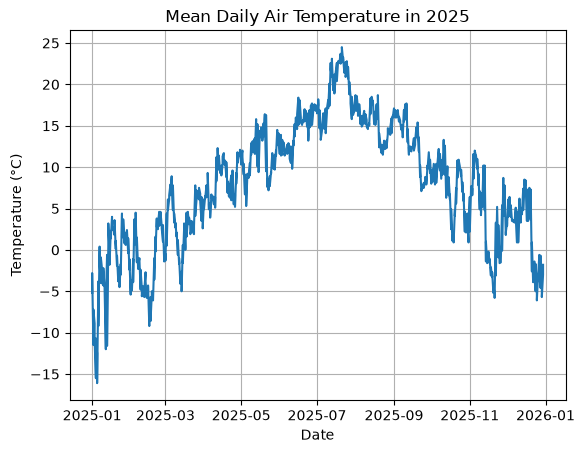

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()

# Define endpoint and parameters
endpoint = "https://frost.met.no/observations/v0.jsonld"
parameters = {
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '2025-01-01/2025-12-31'
}

# Issue an HTTP GET request
r = requests.get(endpoint, params=parameters, auth=(client_id, ''))

# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json['data']
    print('Data retrieved from frost.met.no!')
else:
    print('Error! Returned status code %s' % r.status_code)
    print('Message: %s' % json['error']['message'])
    print('Reason: %s' % json['error']['reason'])

# This will return a Dataframe with all of the observations in a table format
df = pd.DataFrame()
rows = []
for i in range(len(data)):
    row = pd.DataFrame(data[i]['observations'])
    row['referenceTime'] = data[i]['referenceTime']
    row['sourceId'] = data[i]['sourceId']
    rows.append(row)

df = pd.concat(rows, ignore_index=True)

# Extract temperatures and dates
temperatures = df["value"]

dates = pd.to_datetime(df["referenceTime"])

# Plot the data
plt.plot(
    dates,
    temperatures
)

# Add labels and title to the plot
plt.title("Mean Daily Air Temperature in 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()